In [1]:
import os

import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import torch
from lightglue import SIFT, LightGlue
from lightglue.utils import numpy_image_to_torch, rbd
from PIL import Image
from transformers import AutoImageProcessor, AutoModel

ModuleNotFoundError: No module named 'torch'

In [2]:
winter = "8"
summer = "38"

img_winter = Image.open(
    f"/mnt/cdisk/emasquil/shadow_dataset/pansharpened_corrected/OMA_177/OMA_177_{winter}_rgb.png"
)
img_summer = Image.open(
    f"/mnt/cdisk/emasquil/shadow_dataset/pansharpened_corrected/OMA_177/OMA_177_{summer}_rgb.png"
)

try:
    matches = np.load(f"/home/emasquil/code/shadow_dataset/debug_ba/ba_files/OMA_177/matches/pairwise_matches/OMA_177_{winter}_pan_OMA_177_{summer}_pan.npy")
except FileNotFoundError:
    matches = np.load(f"/home/emasquil/code/shadow_dataset/debug_ba/ba_files/OMA_177/matches/pairwise_matches/OMA_177_{summer}_pan_OMA_177_{winter}_pan.npy")

print("ok")

ok


In [3]:
print("Matches from bundle adjustment")
print(len(matches))

Matches from bundle adjustment
10


(np.float64(-0.5), np.float64(1406.5), np.float64(1602.5), np.float64(-0.5))

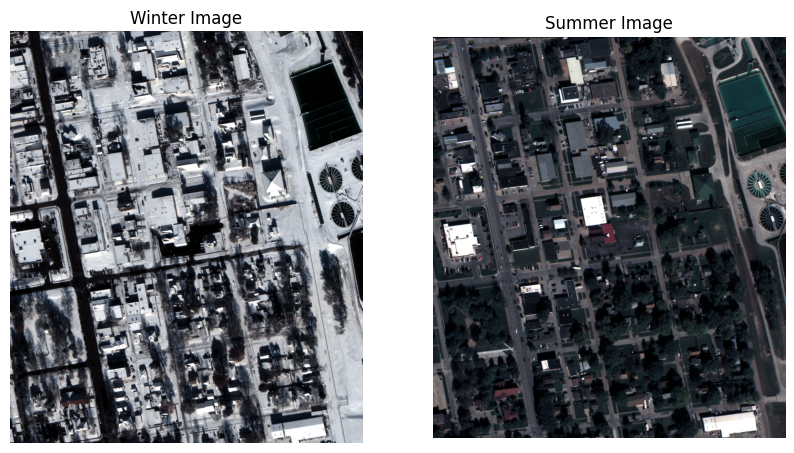

In [4]:
plt.figure(figsize=(10, 20))
plt.subplot(1, 2, 1)
plt.imshow(img_winter)
plt.title("Winter Image")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(img_summer)
plt.title("Summer Image")
plt.axis("off")

In [5]:
def ransac_filter_matches(kp1, kp2, matches, ransac_thr=0.3):
    """
    Filters matches using RANSAC and a fundamental matrix.

    Args:
        kp1 (list): Keypoints from image 1 (cv.KeyPoint list)
        kp2 (list): Keypoints from image 2 (cv.KeyPoint list)
        matches (list): List of cv.DMatch objects

    Returns:
        inlier_matches (list): Filtered list of inlier cv.DMatch
        mask (np.ndarray): Binary mask of inliers (1) and outliers (0)
    """
    if len(matches) < 8:
        print("Not enough matches for RANSAC.")
        return [], None

    pts1 = np.float32([kp1[m.queryIdx].pt for m in matches]).reshape(-1, 1, 2)
    pts2 = np.float32([kp2[m.trainIdx].pt for m in matches]).reshape(-1, 1, 2)

    F, mask = cv.findFundamentalMat(pts1, pts2, cv.FM_RANSAC, ransac_thr)

    if mask is None:
        print("RANSAC failed to find a fundamental matrix.")
        return [], None

    inlier_matches = [m for m, inlier in zip(matches, mask.ravel()) if inlier]
    print(f"RANSAC inliers: {len(inlier_matches)} / {len(matches)}")
    return inlier_matches, mask


def draw_matches(img1, img2, kp1, kp2, matches, color=(0, 255, 0), thickness=2, radius=5):
    """
    Draws matches with custom style.

    Args:
        img1 (np.ndarray): First image
        img2 (np.ndarray): Second image
        kp1 (list): Keypoints from image 1
        kp2 (list): Keypoints from image 2
        matches (list): List of cv.DMatch objects
        color (tuple): BGR color for lines and keypoints
        thickness (int): Line thickness
        radius (int): Keypoint circle radius

    Returns:
        output (np.ndarray): Image with matches drawn
    """
    h1, w1 = img1.shape[0:2]
    h2, w2 = img2.shape[0:2]
    output = np.zeros((max(h1, h2), w1 + w2, 3), dtype=np.uint8)
    output[:h1, :w1] = cv.cvtColor(img1, cv.COLOR_RGB2BGR)
    output[:h2, w1:] = cv.cvtColor(img2, cv.COLOR_RGB2BGR)

    for m in matches:
        pt1 = tuple(np.round(kp1[m.queryIdx].pt).astype(int))
        pt2 = tuple(np.round(kp2[m.trainIdx].pt).astype(int) + np.array([w1, 0]))  # Shift pt2 by width of img1

        # Draw keypoints
        cv.circle(output, pt1, radius, color, -1)
        cv.circle(output, pt2, radius, color, -1)

        # Draw line
        cv.line(output, pt1, pt2, color, thickness, lineType=cv.LINE_AA)

    return cv.cvtColor(output, cv.COLOR_BGR2RGB)

## SIFT

In [6]:
"""
# Preprocess images
img1_gray = cv.cvtColor(np.array(img_winter), cv.COLOR_RGB2GRAY)
img2_gray = cv.cvtColor(np.array(img_summer), cv.COLOR_RGB2GRAY)

# Detect features
sift = cv.SIFT_create()
kp1, des1 = sift.detectAndCompute(img1_gray, None)
kp2, des2 = sift.detectAndCompute(img2_gray, None)

# Match descriptors
bf = cv.BFMatcher()
raw_matches = bf.match(des1, des2)

inlier_matches, mask = ransac_filter_matches(kp1, kp2, raw_matches)

output_img = draw_matches(np.array(img_winter), np.array(img_summer), kp1, kp2, inlier_matches,
                          color=(0, 0, 255), thickness=3, radius=6)

plt.figure(figsize=(15, 10))
plt.imshow(output_img)
plt.axis('off')
plt.show()
"""

"\n# Preprocess images\nimg1_gray = cv.cvtColor(np.array(img_winter), cv.COLOR_RGB2GRAY)\nimg2_gray = cv.cvtColor(np.array(img_summer), cv.COLOR_RGB2GRAY)\n\n# Detect features\nsift = cv.SIFT_create()\nkp1, des1 = sift.detectAndCompute(img1_gray, None)\nkp2, des2 = sift.detectAndCompute(img2_gray, None)\n\n# Match descriptors\nbf = cv.BFMatcher()\nraw_matches = bf.match(des1, des2)\n\ninlier_matches, mask = ransac_filter_matches(kp1, kp2, raw_matches)\n\noutput_img = draw_matches(np.array(img_winter), np.array(img_summer), kp1, kp2, inlier_matches,\n                          color=(0, 0, 255), thickness=3, radius=6)\n\nplt.figure(figsize=(15, 10))\nplt.imshow(output_img)\nplt.axis('off')\nplt.show()\n"

## LightGLUE

In [7]:
def keypoints_to_cv2_keypoints(kpts):
    """Convert Nx2 numpy array or tensor of (x, y) to list of cv2.KeyPoint."""
    return [cv.KeyPoint(float(x), float(y), size=1) for x, y in kpts]

def lightglue_to_cv2_dmatches(scores):
    """
    Create fake cv2.DMatch objects for LightGlue matches.
    _queryIdx and _trainIdx are assumed to be in the same order as keypoints.
    """
    return [
        cv.DMatch(_queryIdx=i, _trainIdx=i, _distance=float(1 - score))  # use (1 - score) so higher scores = lower distances
        for i, score in enumerate(scores)
    ]

### Superpoint + LightGlue (huggingface implementation)

In [8]:
images = [img_winter, img_summer]

processor = AutoImageProcessor.from_pretrained("ETH-CVG/lightglue_superpoint")
model = AutoModel.from_pretrained("ETH-CVG/lightglue_superpoint")

inputs = processor(images, return_tensors="pt")
with torch.no_grad():
    outputs = model(**inputs)


image_sizes = [[(image.height, image.width) for image in images]]
outputs = processor.post_process_keypoint_matching(outputs, image_sizes, threshold=0.2)

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


In [9]:
"""
light_glue_output = outputs[0]

# convert tensors to numpy
kpts0_np = light_glue_output['keypoints0'].cpu().numpy()
kpts1_np = light_glue_output['keypoints1'].cpu().numpy()
scores_np = light_glue_output['matching_scores'].cpu().numpy()

# convert to OpenCV keypoints and matches
kp1_cv = keypoints_to_cv2_keypoints(kpts0_np)
kp2_cv = keypoints_to_cv2_keypoints(kpts1_np)
matches_cv = lightglue_to_cv2_dmatches(scores_np)

inlier_matches, mask = ransac_filter_matches(kp1_cv, kp2_cv, matches_cv)

output_img_lightglue = draw_matches(np.array(img_winter), np.array(img_summer), kp1_cv, kp2_cv, inlier_matches,
                                    color=(0, 255, 0), thickness=3, radius=6)

plt.figure(figsize=(15, 10))
plt.imshow(output_img_lightglue)
plt.axis('off')
"""

"\nlight_glue_output = outputs[0]\n\n# convert tensors to numpy\nkpts0_np = light_glue_output['keypoints0'].cpu().numpy()\nkpts1_np = light_glue_output['keypoints1'].cpu().numpy()\nscores_np = light_glue_output['matching_scores'].cpu().numpy()\n\n# convert to OpenCV keypoints and matches\nkp1_cv = keypoints_to_cv2_keypoints(kpts0_np)\nkp2_cv = keypoints_to_cv2_keypoints(kpts1_np)\nmatches_cv = lightglue_to_cv2_dmatches(scores_np)\n\ninlier_matches, mask = ransac_filter_matches(kp1_cv, kp2_cv, matches_cv)\n\noutput_img_lightglue = draw_matches(np.array(img_winter), np.array(img_summer), kp1_cv, kp2_cv, inlier_matches,\n                                    color=(0, 255, 0), thickness=3, radius=6)\n\nplt.figure(figsize=(15, 10))\nplt.imshow(output_img_lightglue)\nplt.axis('off')\n"

### SIFT + LightGlue (native implementation)

In [10]:
# --- CONFIG ---
MAX_KEYPOINTS = 10_000
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
matcher = LightGlue(features='sift').eval().to(DEVICE)

"""
extractor = SIFT(max_num_keypoints=MAX_KEYPOINTS).eval().to(DEVICE)

image0 = numpy_image_to_torch(np.array(img_winter)).to(DEVICE)  # shape: (3,H,W)
image1 = numpy_image_to_torch(np.array(img_summer)).to(DEVICE)

feats0_o = extractor.extract(image0)  # dict: keypoints (Nx2), descriptors (Nx128)
feats1_o = extractor.extract(image1)

matches01_o = matcher({'image0': feats0_o, 'image1': feats1_o})

# remove batch dimension - ligthglue utils
feats0, feats1, matches01 = [rbd(x) for x in [feats0_o, feats1_o, matches01_o]]

matches = matches01['matches']  # (K,2) array: indices of matched keypoints
scores = matches01['scores']    # (K,) confidence for each match

# get matched keypoint coordinates
points0 = feats0['keypoints'][matches[:, 0]]  # shape (K,2)
points1 = feats1['keypoints'][matches[:, 1]]  # shape (K,2)

print(f"Found {len(matches)} matches (LightGlue SIFT)")

# convert to opencv matches for drawing and filtering with
cv_matches = [
    cv.DMatch(_queryIdx=int(i), _trainIdx=int(j), _distance=float(1 - s))
    for (i, j), s in zip(matches, scores)
]

inliers, _ = ransac_filter_matches(
    kp1=[cv.KeyPoint(x=float(x), y=float(y), size=1) for x, y in feats0['keypoints']],
    kp2=[cv.KeyPoint(x=float(x), y=float(y), size=1) for x, y in feats1['keypoints']],
    matches=cv_matches,
)



output_img = draw_matches(
    np.array(img_winter), np.array(img_summer),
    [cv.KeyPoint(x=float(x), y=float(y), size=1) for x, y in feats0['keypoints']],
    [cv.KeyPoint(x=float(x), y=float(y), size=1) for x, y in feats1['keypoints']],
    inliers, color=(255, 0, 255), thickness=2, radius=4
)


plt.figure(figsize=(15, 10))
plt.imshow(output_img)
plt.axis('off')
"""

'\nextractor = SIFT(max_num_keypoints=MAX_KEYPOINTS).eval().to(DEVICE)\n\nimage0 = numpy_image_to_torch(np.array(img_winter)).to(DEVICE)  # shape: (3,H,W)\nimage1 = numpy_image_to_torch(np.array(img_summer)).to(DEVICE)\n\nfeats0_o = extractor.extract(image0)  # dict: keypoints (Nx2), descriptors (Nx128)\nfeats1_o = extractor.extract(image1)\n\nmatches01_o = matcher({\'image0\': feats0_o, \'image1\': feats1_o})\n\n# remove batch dimension - ligthglue utils\nfeats0, feats1, matches01 = [rbd(x) for x in [feats0_o, feats1_o, matches01_o]]\n\nmatches = matches01[\'matches\']  # (K,2) array: indices of matched keypoints\nscores = matches01[\'scores\']    # (K,) confidence for each match\n\n# get matched keypoint coordinates\npoints0 = feats0[\'keypoints\'][matches[:, 0]]  # shape (K,2)\npoints1 = feats1[\'keypoints\'][matches[:, 1]]  # shape (K,2)\n\nprint(f"Found {len(matches)} matches (LightGlue SIFT)")\n\n# convert to opencv matches for drawing and filtering with\ncv_matches = [\n    cv.D

### OpenCV SIFT + LightGlue (native implementation)

In [11]:
from lightglue.sift import sift_to_rootsift

def opencv_sift_to_lightglue_format(opencv_sift_features, image_size=None, device="cuda:0", rootsift=True):
    """
    opencv_sift_features is an array with shape Nx132
    (col, row, scale, orientation) in columns 0-3 and (sift_descriptor) in the following 128 columns
    image_size, if specified, is expected to be a tuple --> image_size = (W, H)
    """
    from lightglue.sift import sift_to_rootsift
    import torch
    assert opencv_sift_features.shape[1] == 132
    lightglue_sift = {
        "keypoints": opencv_sift_features[:, :2],
        "scales": opencv_sift_features[:, 2],
        "oris": np.deg2rad(opencv_sift_features[:, 3]),
        "descriptors": opencv_sift_features[:, 4:]
    }
    # TODO opencv keypoint responses (equivalent to lightglue scores) are not used here for compatiblity
    # maybe in the future keypoint responses should be incorporated to further improve lightglue performance
    if image_size is not None:
        lightglue_sift["image_size"] = np.array(image_size)
    for k in lightglue_sift:
        lightglue_sift[k] = torch.Tensor(lightglue_sift[k][np.newaxis, ...]).to(device)
    if rootsift:
        # lightglue normalization - by default is true
        lightglue_sift["descriptors"] = sift_to_rootsift(lightglue_sift["descriptors"])
    return lightglue_sift


def get_Nlargest_points(opencv_sift_features, max_kp=10000):
    features_i = opencv_sift_features
    features_i_final = np.zeros((max_kp, 132))
    features_i_final[:] = np.nan
    features_i_final[: min(features_i.shape[0], max_kp)] = features_i[:max_kp]
    return features_i_final
    

mask = None
sift = cv.SIFT_create() # cv2.xfeatures2d.SIFT_create() for older opencv versions


input_im = np.array(img_winter)
kp, des = sift.detectAndCompute(input_im.astype(np.uint8), mask)
features = np.array([[*k.pt, k.size, k.angle, *d] for k, d in zip(kp, des)])
features = get_Nlargest_points(features, 10000)
H, W = input_im.shape[:2]
feats0_ = opencv_sift_to_lightglue_format(features)

input_im = np.array(img_summer)
kp, des = sift.detectAndCompute(input_im.astype(np.uint8), mask)
features = np.array([[*k.pt, k.size, k.angle, *d] for k, d in zip(kp, des)])
features = get_Nlargest_points(features, 10000)
H, W = input_im.shape[:2]
feats1_ = opencv_sift_to_lightglue_format(features)

print("ok")

ok


Found 86 matches (LightGlue SIFT)
RANSAC inliers: 25 / 86


(np.float64(-0.5), np.float64(2760.5), np.float64(1602.5), np.float64(-0.5))

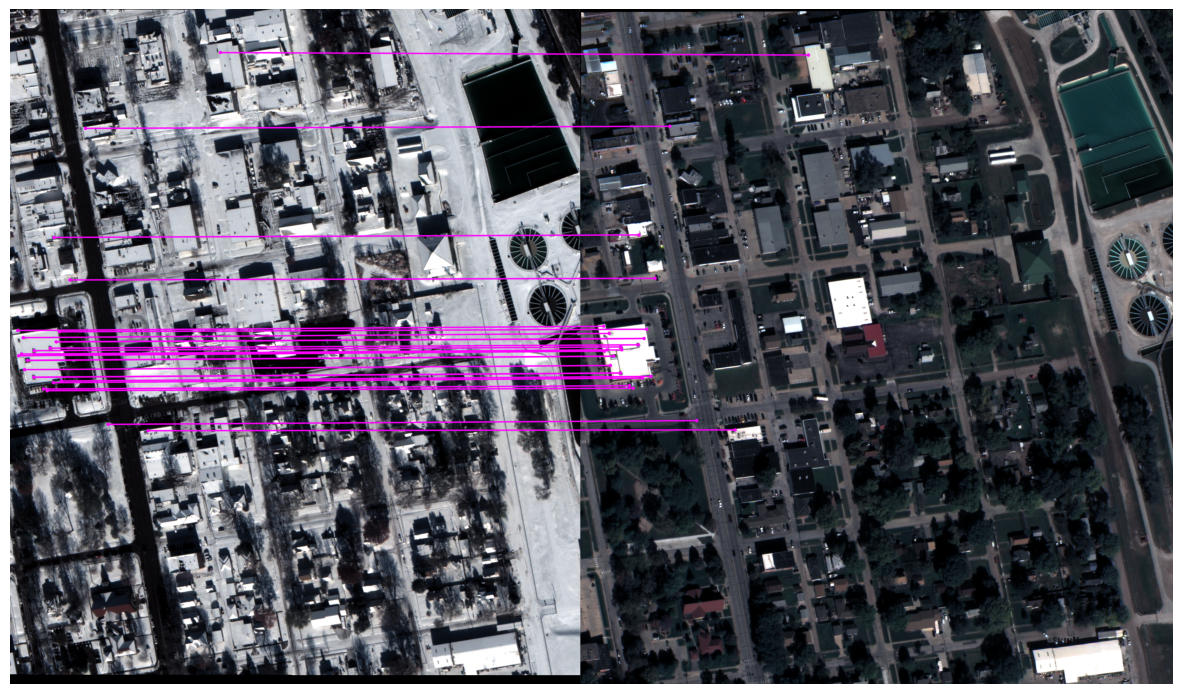

In [21]:
matches01 = matcher({'image0': feats0_, 'image1': feats1_})

# remove batch dimension - ligthglue utils
feats0, feats1, matches01 = [rbd(x) for x in [feats0_, feats1_, matches01]]

matches = matches01['matches']  # (K,2) array: indices of matched keypoints
scores = matches01['scores']    # (K,) confidence for each match

# get matched keypoint coordinates
points0 = feats0['keypoints'][matches[:, 0]]  # shape (K,2)
points1 = feats1['keypoints'][matches[:, 1]]  # shape (K,2)

print(f"Found {len(matches)} matches (LightGlue SIFT)")

# convert to opencv matches for drawing and filtering with
cv_matches = [
    cv.DMatch(_queryIdx=int(i), _trainIdx=int(j), _distance=float(1 - s))
    for (i, j), s in zip(matches, scores)
]

inliers, ransac_mask = ransac_filter_matches(
    kp1=[cv.KeyPoint(x=float(x), y=float(y), size=1) for x, y in feats0['keypoints']],
    kp2=[cv.KeyPoint(x=float(x), y=float(y), size=1) for x, y in feats1['keypoints']],
    matches=cv_matches,
)



output_img = draw_matches(
    np.array(img_winter), np.array(img_summer),
    [cv.KeyPoint(x=float(x), y=float(y), size=1) for x, y in feats0['keypoints']],
    [cv.KeyPoint(x=float(x), y=float(y), size=1) for x, y in feats1['keypoints']],
    inliers, color=(255, 0, 255), thickness=2, radius=4
)


plt.figure(figsize=(15, 10))
plt.imshow(output_img)
plt.axis('off')

In [17]:
inliers[0].queryIdx

328

In [18]:
inliers[0].trainIdx

399

In [24]:
ransac_mask.shape

(86, 1)

In [25]:
scores[ransac_mask.ravel()]

/tmp/ipykernel_1351300/1233985519.py:1: UserWarning: indexing with dtype torch.uint8 is now deprecated, please use a dtype torch.bool instead. (Triggered internally at /pytorch/aten/src/ATen/native/IndexingUtils.h:29.)
  scores[ransac_mask.ravel()]


tensor([0.4135, 0.8791, 0.2028, 0.1999, 0.7459, 0.2048, 0.1337, 0.2037, 0.2221,
        0.3296, 0.1228, 0.2889, 0.3403, 0.6485, 0.2418, 0.3819, 0.3353, 0.2719,
        0.4265, 0.9111, 0.1887, 0.1382, 0.1523, 0.3390, 0.1076],
       device='cuda:0', grad_fn=<IndexBackward0>)

In [ ]:
scores.shape

In [30]:
scores = scores.detach().cpu().numpy()
matches = matches.detach().cpu().numpy()

sorted_indices = np.argsort(-scores.ravel()) # sort from major to minor
scores_sorted = scores[sorted_indices]
matches_sorted = matches[sorted_indices]

print(scores_sorted)
print(matches_sorted)

[0.91113925 0.8849581  0.87905097 0.8789003  0.81669956 0.7766983
 0.74586105 0.64850706 0.63625646 0.5943844  0.5643187  0.5238141
 0.51146966 0.4740518  0.47343644 0.43169022 0.42653227 0.41623157
 0.4134585  0.38597903 0.38189507 0.36646804 0.36197194 0.35630178
 0.35562444 0.35283604 0.34032875 0.3390418  0.33527157 0.3319439
 0.33109096 0.3296217  0.29216778 0.29167613 0.28886905 0.28524768
 0.27193546 0.27157372 0.25053567 0.24456672 0.2417664  0.24165626
 0.23086135 0.22962241 0.22209269 0.21442413 0.21261224 0.20656808
 0.20538922 0.20482342 0.2036858  0.20278229 0.19991435 0.19671574
 0.18871103 0.18582156 0.17524806 0.16220169 0.15230769 0.1503509
 0.14881274 0.14797038 0.14172174 0.13884275 0.13817498 0.13751175
 0.13748609 0.13366376 0.12462199 0.12282325 0.12156241 0.12031575
 0.11761627 0.11711384 0.11334513 0.11043242 0.10978416 0.1093862
 0.10932498 0.10759351 0.1069838  0.10680614 0.10513845 0.10229257
 0.10100461 0.10069928]
[[2263 1348]
 [ 493  506]
 [ 351  416]
 [ 9

In [29]:
matches[:7, :]

tensor([[ 64, 181],
        [ 95, 284],
        [102,  75],
        [125, 326],
        [175,  50],
        [273, 352],
        [328, 399]], device='cuda:0')

In [19]:
matches

tensor([[  64,  181],
        [  95,  284],
        [ 102,   75],
        [ 125,  326],
        [ 175,   50],
        [ 273,  352],
        [ 328,  399],
        [ 343,  241],
        [ 351,  416],
        [ 383,  414],
        [ 430,  456],
        [ 467,  348],
        [ 478,  466],
        [ 493,  506],
        [ 516,  509],
        [ 559,  522],
        [ 597,  549],
        [ 715,  626],
        [ 731,  633],
        [ 732,  634],
        [ 754,  569],
        [ 869,  649],
        [ 915,  735],
        [ 916,  747],
        [ 950,  733],
        [ 965,  648],
        [1019,  814],
        [1027,  778],
        [1028,  779],
        [1033,  776],
        [1037,  785],
        [1052,  806],
        [1101,  709],
        [1125,  833],
        [1199,  710],
        [1284,  886],
        [1339,  982],
        [1448,  967],
        [1510,  811],
        [1599, 1026],
        [1709, 1088],
        [1723, 1089],
        [1761, 1104],
        [1786, 1114],
        [1817, 1128],
        [1

In [28]:
a = torch.Tensor([])
print(a.detach().cpu().numpy())

[]


In [34]:
extractor.conf

namespace(rootsift=True,
          nms_radius=0,
          max_num_keypoints=10000,
          backend='opencv',
          detection_threshold=0.0066667,
          edge_threshold=10,
          first_octave=-1,
          num_octaves=4)